# $\mathrm{K}_{\mathrm{V}}2.1$ L403A mutation-site distance analysis

Default ensemble subset: **allOk3 + structural/interface QC** (`all_ok_3_structural_interface_qc`; corrected 3 Å convergence, G377 tetramer-integrity filtering, and a 27 Å pore–VSD interface cutoff).

We focus on experimental/paper residue L403A (model/CSV L405A) and tests whether the mutation shifts the intracellular helix/gate geometry. All visible aliases use experimental numbering; WT (8SD3) and L403A (8SDA) experimental Cα distances are overlaid.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
repo_root = Path.cwd() if (Path.cwd()/"shared").is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo_root))
import importlib
import shared.plotting as shared_plotting
importlib.reload(shared_plotting)  # Pick up newly added plotting helpers in an active kernel.
from shared.plotting import KV21_PALETTE, experimental_reference_style, plot_split_ensemble_with_experimentals, plot_protocol_split_with_experimentals, plot_l403a_e423_n179_figure, plot_l403a_e423_n179_asymmetry, apply_kv21_style
import shared.dataset_selection as shared_dataset_selection
importlib.reload(shared_dataset_selection)
from shared.dataset_selection import distance_csv_options, load_selected_distance_csv
apply_kv21_style()


In [2]:
from shared.presentation_export import install_notebook_figure_export
WRITING_FIGURE_DIR = repo_root.parent / 'vgci_mutants_writing' / 'figures' / 'kv21'
install_notebook_figure_export(WRITING_FIGURE_DIR, 'Kv21_L403A_mutationSite_analysis')


PosixPath('/Users/ahernandezgonzalez/Repositories/vgci_mutants_writing/figures/kv21/Kv21_L403A_mutationSite_analysis')

In [3]:
DATASET_SELECTION = 'all_ok_3_structural_interface_alignment_qc'  # Final convergence, tetramer, interface, and v2 alignment QC.
data = repo_root / 'kv21' / 'dataDistances'
DATASET_PATHS = {
    'WT masked': distance_csv_options(repo_root, data / '26-02-11_Kv2.1_wt_maskedAF2_distances_all.csv', 'Kv21', 'WT', 'masked'),
    'L403A masked': distance_csv_options(repo_root, data / '26-02-11_Kv2.1_l403a_maskedAF2_distances_all.csv', 'Kv21', 'L403A', 'masked'),
    'WT vanilla': distance_csv_options(repo_root, data / '26-02-11_Kv2.1_wt_vanillaAF2_distances_all.csv', 'Kv21', 'WT', 'vanilla'),
    'L403A vanilla': distance_csv_options(repo_root, data / '26-02-11_Kv2.1_l403a_vanillaAF2_distances_all.csv', 'Kv21', 'L403A', 'vanilla'),
}
DATASET_PATHS
df_wt_masked=load_selected_distance_csv('WT masked',DATASET_PATHS['WT masked'],DATASET_SELECTION); df_l403a_masked=load_selected_distance_csv('L403A masked',DATASET_PATHS['L403A masked'],DATASET_SELECTION)
df_wt_vanilla=load_selected_distance_csv('WT vanilla',DATASET_PATHS['WT vanilla'],DATASET_SELECTION); df_l403a_vanilla=load_selected_distance_csv('L403A vanilla',DATASET_PATHS['L403A vanilla'],DATASET_SELECTION)
print({k:v.shape for k,v in [("WT masked",df_wt_masked),("L403A masked",df_l403a_masked)]})


WT masked: requested=all_ok_3_structural_interface_alignment_qc; actual=all_ok_3_structural_interface_alignment_qc; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv
L403A masked: requested=all_ok_3_structural_interface_alignment_qc; actual=all_ok_3_structural_interface_alignment_qc; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/kv21/dataDistances/26-02-11_Kv2.1_l403a_maskedAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv


WT vanilla: requested=all_ok_3_structural_interface_alignment_qc; actual=all_ok_3_structural_interface_alignment_qc; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/kv21/dataDistances/26-02-11_Kv2.1_wt_vanillaAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv
L403A vanilla: requested=all_ok_3_structural_interface_alignment_qc; actual=all_ok_3_structural_interface_alignment_qc; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/kv21/dataDistances/26-02-11_Kv2.1_l403a_vanillaAF2_distances_all_ok_rmsd_3A_structural_interface_alignment_qc.csv


{'WT masked': (3658, 1411), 'L403A masked': (3693, 1411)}


In [4]:
# Visible aliases use experimental numbering; values are read from unchanged model/CSV columns (+2).
aliases={
 "A_A402-B_A402":"CA_CA_A_ALA404_CA-B_ALA404_CA", "A_A402-C_A402":"CA_CA_A_ALA404_CA-C_ALA404_CA", "A_A402-D_A402":"CA_CA_A_ALA404_CA-D_ALA404_CA",
 "B_A402-C_A402":"CA_CA_B_ALA404_CA-C_ALA404_CA", "B_A402-D_A402":"CA_CA_B_ALA404_CA-D_ALA404_CA", "C_A402-D_A402":"CA_CA_C_ALA404_CA-D_ALA404_CA",
 "A_F236-A_R289":"CA_CA_A_ARG291_CA-A_PHE238_CA", "A_F236-A_R308":"CA_CA_A_ARG310_CA-A_PHE238_CA",
}
aliases={a:c for a,c in aliases.items() if c in df_wt_masked.columns and c in df_l403a_masked.columns}
print("Available mutation-site columns:", list(aliases))
print('Mutation-site distributions are plotted below after coordinate-derived experimental distances are loaded.')


Available mutation-site columns: ['A_A402-B_A402', 'A_A402-C_A402', 'A_A402-D_A402', 'B_A402-C_A402', 'B_A402-D_A402', 'C_A402-D_A402', 'A_F236-A_R289', 'A_F236-A_R308']
Mutation-site distributions are plotted below after coordinate-derived experimental distances are loaded.


## Vanilla comparison and experimental shift ranking


In [5]:
# Repeat the mutation-site comparison for vanilla ensembles.
print('Vanilla mutation-site distributions are included in the experimental comparison section below.')

# Rank the experimental WT -> L403A shifts (8SD3 versus 8SDA).
wt_exp = {"A_A402-B_A402":10.477,"A_A402-C_A402":10.465,"A_A402-D_A402":14.815,"B_A402-C_A402":14.808,"B_A402-D_A402":10.480,"C_A402-D_A402":10.470,"A_F236-A_R289":25.412,"A_F236-A_R308":13.004}
mut_exp = {"A_A402-B_A402":10.159,"A_A402-C_A402":12.553,"A_A402-D_A402":8.202,"B_A402-C_A402":10.117,"B_A402-D_A402":12.460,"C_A402-D_A402":7.248,"A_F236-A_R289":24.752,"A_F236-A_R308":13.550}
shift_table = pd.DataFrame({"distance":list(wt_exp), "WT_8SD3":list(wt_exp.values()), "L403A_8SDA":[mut_exp[k] for k in wt_exp]})
shift_table["shift_A"] = shift_table["L403A_8SDA"] - shift_table["WT_8SD3"]
shift_table["abs_shift_A"] = shift_table["shift_A"].abs()
shift_table = shift_table.sort_values("abs_shift_A", ascending=False)
display(shift_table)


Vanilla mutation-site distributions are included in the experimental comparison section below.


,distance,WT_8SD3,L403A_8SDA,shift_A,abs_shift_A
2,A_A402-D_A402,14.815,8.202,-6.613,6.613
3,B_A402-C_A402,14.808,10.117,-4.691,4.691
5,C_A402-D_A402,10.470,7.248,-3.222,3.222
1,A_A402-C_A402,10.465,12.553,2.088,2.088
4,B_A402-D_A402,10.480,12.460,1.980,1.980
6,A_F236-A_R289,25.412,24.752,-0.660,0.660
7,A_F236-A_R308,13.004,13.550,0.546,0.546
0,A_A402-B_A402,10.477,10.159,-0.318,0.318


## Four-chain neighborhood shift analysis


In [6]:
## Four-subunit pore–voltage-sensor interface distances
# These are same-subunit contacts from the intracellular pore/S6-side K427, E423, and K420
# to voltage-sensor-side N179 and V182, repeated across chains A–D.
residue_pairs = [("LYS429","ASN181"),("LYS429","VAL184"),("GLU425","ASN181"),("GLU425","VAL184"),("LYS422","ASN181"),("LYS422","VAL184"),("VAL411","VAL400"),("VAL411","ILE403"),("VAL411","ALA404"),("VAL411","LEU405"),("VAL411","PRO408"),("VAL411","ILE409"),("PHE414","LEU401"),("PHE414","ILE409"),("PHE414","TYR418")]
one_letter = {'LYS':'K', 'ASN':'N', 'VAL':'V', 'GLU':'E', 'ILE':'I', 'ALA':'A', 'LEU':'L', 'PRO':'P', 'PHE':'F', 'TYR':'Y'}
chain_aliases={}
for chain in "ABCD":
    for r1,r2 in residue_pairs:
        n1=int(''.join(x for x in r1[1:] if x.isdigit()))-2; n2=int(''.join(x for x in r2[1:] if x.isdigit()))-2
        label=f"{one_letter[r1[:3]]}{n1}{chain}-{one_letter[r2[:3]]}{n2}{chain}"
        col=f"CA_CA_{chain}_{r1}_CA-{chain}_{r2}_CA"
        chain_aliases[label]=col
chain_aliases={a:c for a,c in chain_aliases.items() if all(c in df.columns for df in (df_wt_masked,df_l403a_masked,df_wt_vanilla,df_l403a_vanilla))}
print(f"Four-subunit pore–VSD interface distances available: {len(chain_aliases)}")
print(list(chain_aliases))
print('Pore–VSD distributions are plotted below only after the experimental overlays are available.')


Four-subunit pore–VSD interface distances available: 24
['K427A-N179A', 'K427A-V182A', 'E423A-N179A', 'E423A-V182A', 'K420A-N179A', 'K420A-V182A', 'K427B-N179B', 'K427B-V182B', 'E423B-N179B', 'E423B-V182B', 'K420B-N179B', 'K420B-V182B', 'K427C-N179C', 'K427C-V182C', 'E423C-N179C', 'E423C-V182C', 'K420C-N179C', 'K420C-V182C', 'K427D-N179D', 'K427D-V182D', 'E423D-N179D', 'E423D-V182D', 'K420D-N179D', 'K420D-V182D']
Pore–VSD distributions are plotted below only after the experimental overlays are available.


## Coordinate-derived experimental distances


In [7]:
from shared.structure_distances import experimental_distances_for_aliases as experimental_for_aliases

## Experimental distances for the plotted residue pairs
import math, re



exp_all_wt, missing_wt = experimental_for_aliases(chain_aliases, "experimental/8SD3.pdb")
exp_all_l403a, missing_l403a = experimental_for_aliases(chain_aliases, "experimental/8SDA.pdb")
print("Calculated WT experimentals:", len(exp_all_wt), "missing:", missing_wt)
print("Calculated L403A experimentals:", len(exp_all_l403a), "missing:", missing_l403a)
# These dictionaries contain every plotted alias that has a valid PDB correspondence.


Calculated WT experimentals: 24 missing: []
Calculated L403A experimentals: 24 missing: []


## Experimental reference values


In [8]:
# CORRECTED experimental dictionary: only motif/ChimeraX-confirmed mappings; unresolved pairs omitted.
EXPERIMENTAL_NEIGHBORHOOD_CORRECTED = {
    'G425A-A181A': {"8SD3_WT": [16.651], "8SDA_L403A": [16.485]},
    'G425A-V184A': {"8SD3_WT": [17.189], "8SDA_L403A": [17.153]},
    'G425B-A181B': {"8SD3_WT": [16.652], "8SDA_L403A": [16.585]},
    'G425B-V184B': {"8SD3_WT": [17.189], "8SDA_L403A": [17.174]},
    'G425C-A181C': {"8SD3_WT": [16.652], "8SDA_L403A": [18.761]},
    'G425C-V184C': {"8SD3_WT": [17.189], "8SDA_L403A": [19.632]},
    'G425D-A181D': {"8SD3_WT": [16.651], "8SDA_L403A": [20.712]},
    'G425D-V184D': {"8SD3_WT": [17.189], "8SDA_L403A": [22.395]},
    'L422A-A181A': {"8SD3_WT": [20.782], "8SDA_L403A": [20.387]},
    'L422A-V184A': {"8SD3_WT": [20.596], "8SDA_L403A": [20.373]},
    'L422B-A181B': {"8SD3_WT": [20.783], "8SDA_L403A": [20.471]},
    'L422B-V184B': {"8SD3_WT": [20.597], "8SDA_L403A": [20.395]},
    'L422C-A181C': {"8SD3_WT": [20.782], "8SDA_L403A": [21.449]},
    'L422C-V184C': {"8SD3_WT": [20.597], "8SDA_L403A": [21.662]},
    'L422D-A181D': {"8SD3_WT": [20.782], "8SDA_L403A": [23.936]},
    'L422D-V184D': {"8SD3_WT": [20.597], "8SDA_L403A": [24.983]},
    'L429A-A181A': {"8SD3_WT": [10.444], "8SDA_L403A": [10.248]},
    'L429A-V184A': {"8SD3_WT": [15.136], "8SDA_L403A": [15.135]},
    'L429B-A181B': {"8SD3_WT": [10.443], "8SDA_L403A": [10.327]},
    'L429B-V184B': {"8SD3_WT": [15.135], "8SDA_L403A": [15.415]},
    'L429C-A181C': {"8SD3_WT": [10.444], "8SDA_L403A": [13.952]},
    'L429C-V184C': {"8SD3_WT": [15.136], "8SDA_L403A": [19.889]},
    'L429D-A181D': {"8SD3_WT": [10.444], "8SDA_L403A": [18.307]},
    'L429D-V184D': {"8SD3_WT": [15.136], "8SDA_L403A": [23.855]},
    'P414A-I409A': {"8SD3_WT": [8.637], "8SDA_L403A": [8.566]},
    'P414A-L401A': {"8SD3_WT": [20.968], "8SDA_L403A": [20.635]},
    'P414A-T418A': {"8SD3_WT": [5.971], "8SDA_L403A": [6.339]},
    'P414B-I409B': {"8SD3_WT": [8.637], "8SDA_L403A": [8.356]},
    'P414B-L401B': {"8SD3_WT": [20.967], "8SDA_L403A": [20.979]},
    'P414B-T418B': {"8SD3_WT": [5.972], "8SDA_L403A": [6.412]},
    'P414C-I409C': {"8SD3_WT": [8.637], "8SDA_L403A": [7.745]},
    'P414C-L401C': {"8SD3_WT": [20.967], "8SDA_L403A": [20.241]},
    'P414C-T418C': {"8SD3_WT": [5.971], "8SDA_L403A": [6.165]},
    'P414D-I409D': {"8SD3_WT": [8.637], "8SDA_L403A": [7.834]},
    'P414D-L401D': {"8SD3_WT": [20.968], "8SDA_L403A": [20.737]},
    'P414D-T418D': {"8SD3_WT": [5.97], "8SDA_L403A": [6.321]},
    'V411A-A404A': {"8SD3_WT": [11.084], "8SDA_L403A": [10.753]},
    'V411A-I403A': {"8SD3_WT": [12.718], "8SDA_L403A": [12.703]},
    'V411A-I409A': {"8SD3_WT": [5.438], "8SDA_L403A": [5.465]},
    'V411A-L405A': {"8SD3_WT": [11.462], "8SDA_L403A": [11.267]},
    'V411A-P408A': {"8SD3_WT": [4.918], "8SDA_L403A": [5.042]},
    'V411A-V400A': {"8SD3_WT": [16.501], "8SDA_L403A": [16.296]},
    'V411B-A404B': {"8SD3_WT": [11.085], "8SDA_L403A": [10.902]},
    'V411B-I403B': {"8SD3_WT": [12.719], "8SDA_L403A": [13.355]},
    'V411B-I409B': {"8SD3_WT": [5.438], "8SDA_L403A": [5.107]},
    'V411B-L405B': {"8SD3_WT": [11.462], "8SDA_L403A": [11.286]},
    'V411B-P408B': {"8SD3_WT": [4.918], "8SDA_L403A": [4.98]},
    'V411B-V400B': {"8SD3_WT": [16.501], "8SDA_L403A": [16.663]},
    'V411C-A404C': {"8SD3_WT": [11.084], "8SDA_L403A": [11.071]},
    'V411C-I403C': {"8SD3_WT": [12.718], "8SDA_L403A": [12.907]},
    'V411C-I409C': {"8SD3_WT": [5.438], "8SDA_L403A": [5.48]},
    'V411C-L405C': {"8SD3_WT": [11.462], "8SDA_L403A": [10.743]},
    'V411C-P408C': {"8SD3_WT": [4.919], "8SDA_L403A": [5.339]},
    'V411C-V400C': {"8SD3_WT": [16.502], "8SDA_L403A": [17.128]},
    'V411D-A404D': {"8SD3_WT": [11.085], "8SDA_L403A": [10.861]},
    'V411D-I403D': {"8SD3_WT": [12.719], "8SDA_L403A": [12.957]},
    'V411D-I409D': {"8SD3_WT": [5.438], "8SDA_L403A": [5.668]},
    'V411D-L405D': {"8SD3_WT": [11.462], "8SDA_L403A": [10.597]},
    'V411D-P408D': {"8SD3_WT": [4.918], "8SDA_L403A": [4.905]},
    'V411D-V400D': {"8SD3_WT": [16.502], "8SDA_L403A": [17.528]},
}
# Rebuild the plotting dictionary from coordinates using the current experimental-numbered aliases.
# This prevents stale model-numbered labels from silently dropping every experimental marker.
EXPERIMENTAL_NEIGHBORHOOD_CORRECTED = {
    alias: {'8SD3_WT': exp_all_wt[alias], '8SDA_L403A': exp_all_l403a[alias]}
    for alias in chain_aliases if alias in exp_all_wt and alias in exp_all_l403a
}
print("Coordinate-matched experimental aliases retained:", len(EXPERIMENTAL_NEIGHBORHOOD_CORRECTED))
print("Omitted aliases lack a resolved Cα atom in at least one experimental structure.")


Coordinate-matched experimental aliases retained: 24
Omitted aliases lack a resolved Cα atom in at least one experimental structure.


/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:312: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


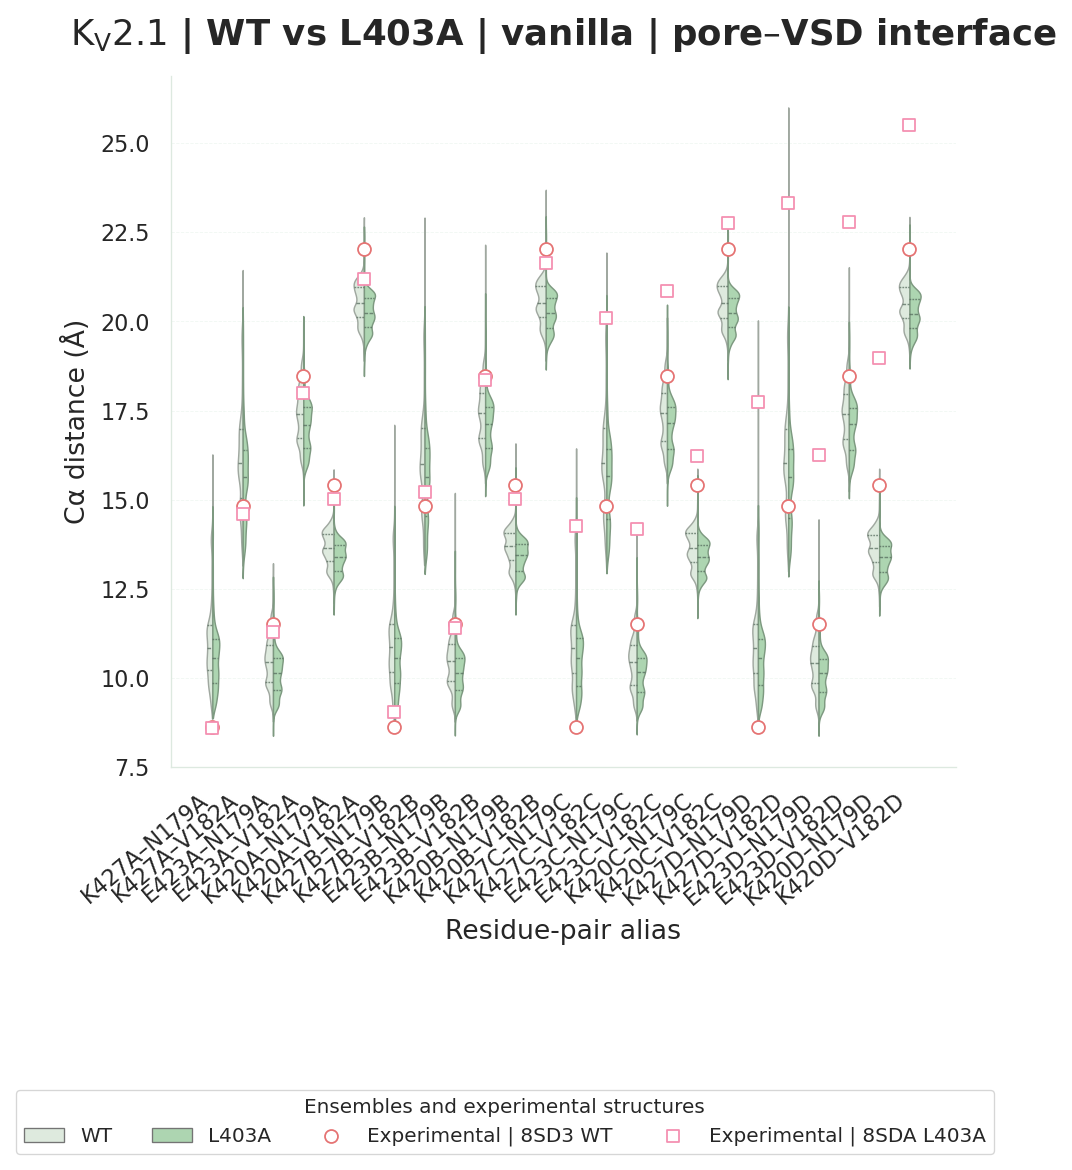

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:312: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


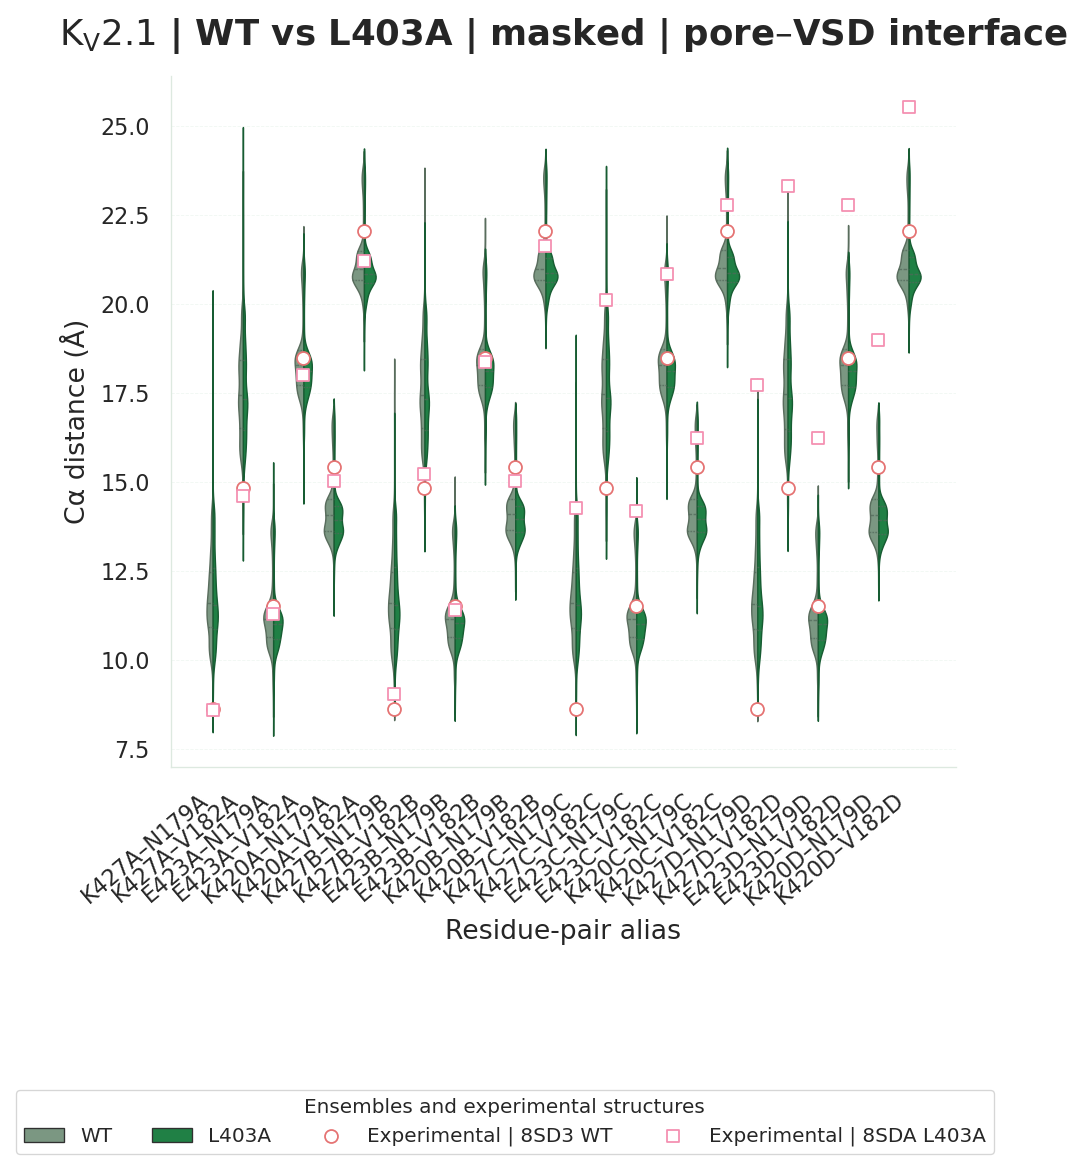

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:312: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


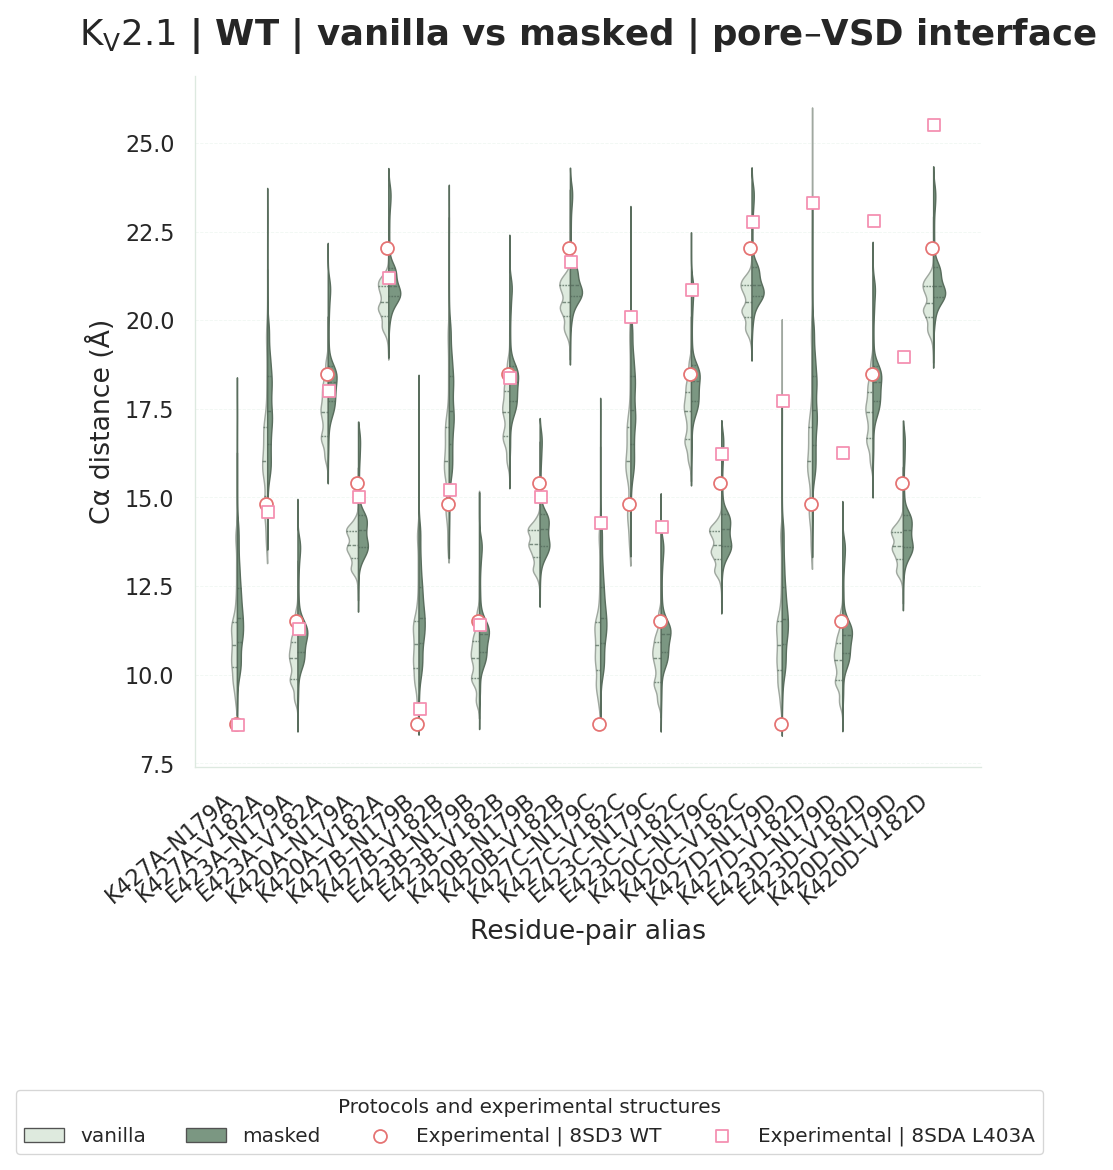

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:312: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


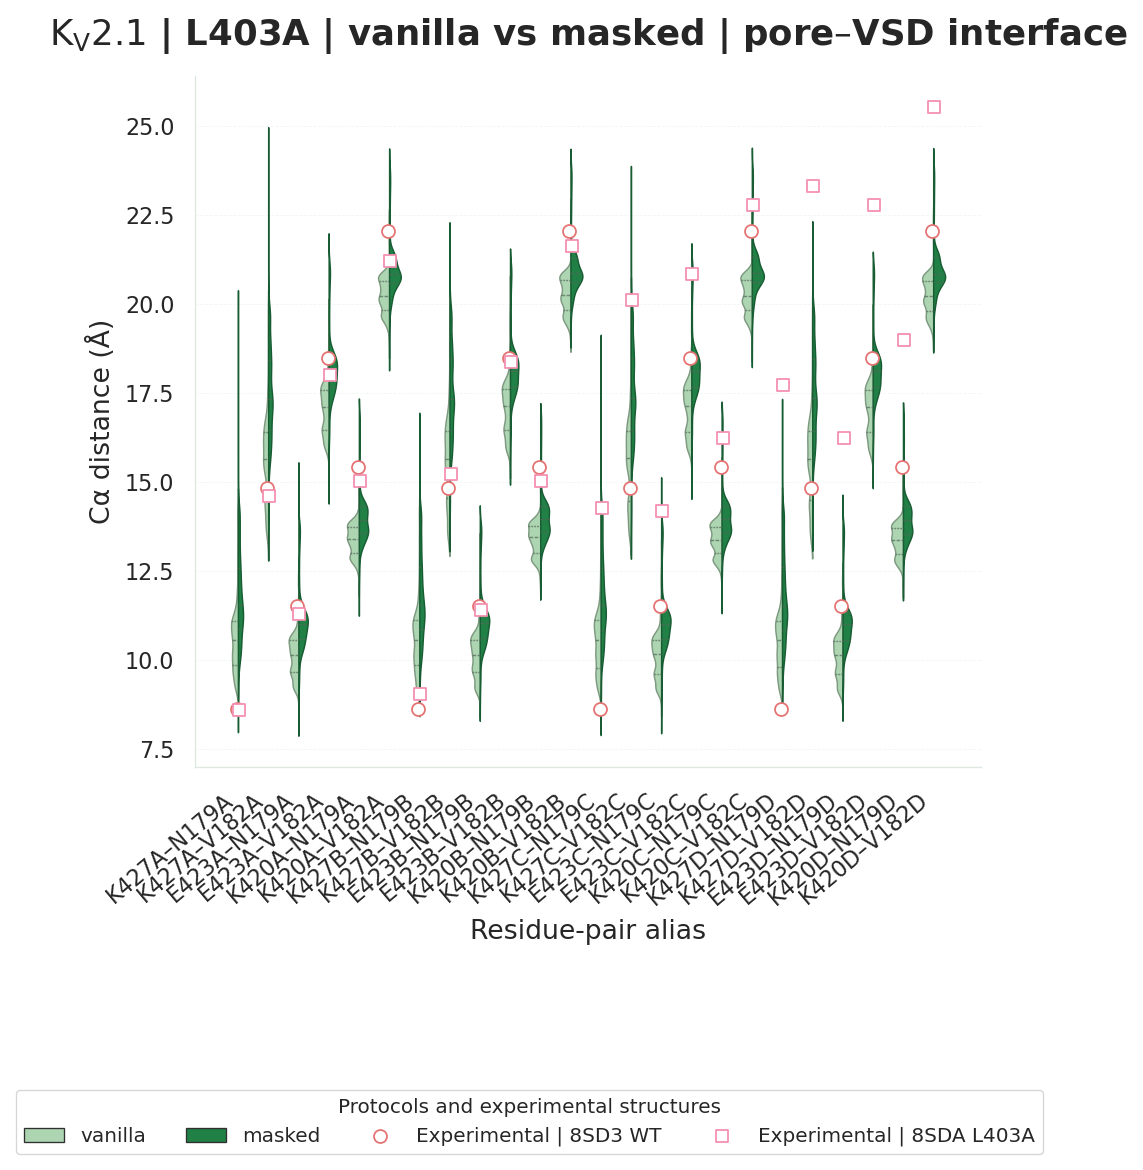

<Axes: title={'center': '$\\mathrm{K}_{\\mathrm{V}}2.1$ | L403A | vanilla vs masked | pore–VSD interface'}, xlabel='Residue-pair alias', ylabel='Cα distance (Å)'>

In [9]:
# Experimental markers used in every split-violin comparison.
protocol_exp_distances = [
    {alias: values['8SD3_WT'] for alias, values in EXPERIMENTAL_NEIGHBORHOOD_CORRECTED.items()},
    {alias: values['8SDA_L403A'] for alias, values in EXPERIMENTAL_NEIGHBORHOOD_CORRECTED.items()},
]
protocol_exp_labels = ['Experimental | 8SD3 WT', 'Experimental | 8SDA L403A']
protocol_exp_colors = [experimental_reference_style(reference)['color'] for reference in ('8SD3', '8SDA')]

# Mutation effect within each protocol.
for protocol, wt_frame, mutant_frame in [
    ('vanilla', df_wt_vanilla, df_l403a_vanilla),
    ('masked', df_wt_masked, df_l403a_masked),
]:
    plot_split_ensemble_with_experimentals(
        wt_frame, mutant_frame, chain_aliases, 'L403A', protocol,
        'pore–VSD interface', protocol_exp_distances,
        protocol_exp_labels, protocol_exp_colors,
    )

# Masking effect within each sequence background.
plot_protocol_split_with_experimentals(
    df_wt_vanilla, df_wt_masked, chain_aliases,
    title='Kv2.1 | WT | vanilla vs masked | pore–VSD interface | experimental distances',
    colors=[KV21_PALETTE['WT_VAN'], KV21_PALETTE['WT_HM']],
    exp_distances_list=protocol_exp_distances,
    dataset_labels=protocol_exp_labels, pdb_colors=protocol_exp_colors,
)
plot_protocol_split_with_experimentals(
    df_l403a_vanilla, df_l403a_masked, chain_aliases,
    title='Kv2.1 | L403A | vanilla vs masked | pore–VSD interface | experimental distances',
    colors=[KV21_PALETTE['L403A_VAN'], KV21_PALETTE['L403A_HM']],
    exp_distances_list=protocol_exp_distances,
    dataset_labels=protocol_exp_labels, pdb_colors=protocol_exp_colors,
)


## Focused pore–VSD interface figure

The complete chain-resolved panel above provides the complete chain-resolved view. For a clearer paper-facing summary, the figure below shows only E423–N179, retaining the full vanilla and masked distributions separately for chains A–D. This makes the asymmetric 8SDA displacement visible without pooling correlated subunits. The key comparison is directional: masking shifts the predicted distributions upward, toward the mutant experimental geometry in chains C and D, but does not reproduce the full displacement.


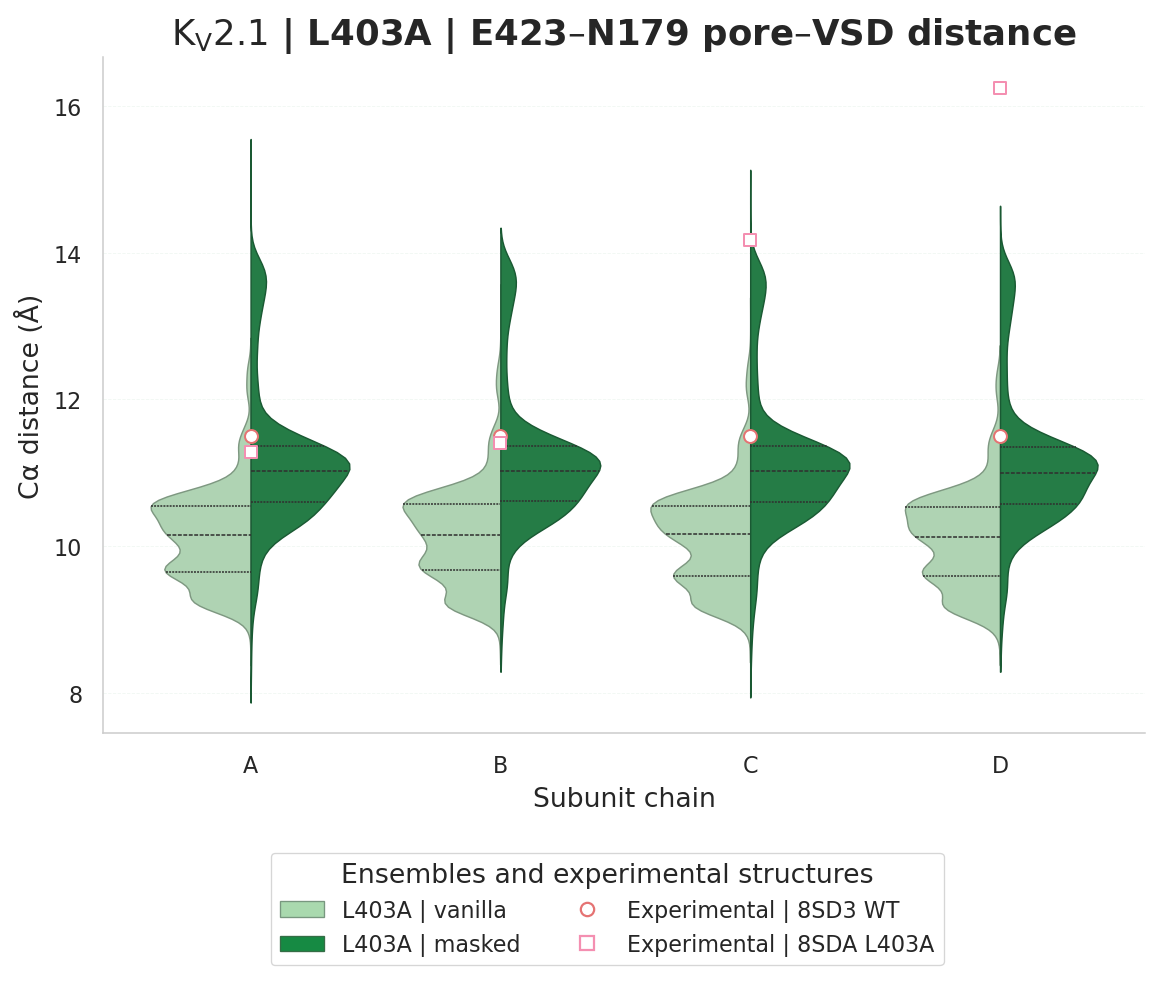

<Axes: title={'center': '$\\mathrm{K}_{\\mathrm{V}}2.1$ | L403A | E423–N179 pore–VSD distance'}, xlabel='Subunit chain', ylabel='Cα distance (Å)'>

In [10]:
plot_l403a_e423_n179_figure(
    df_l403a_vanilla,
    df_l403a_masked,
    chain_aliases,
    protocol_exp_distances[0],
    protocol_exp_distances[1],
)


## Does the E423–N179 shift occur in two subunits?

The L403A experimental structure is asymmetric: two E423–N179 distances remain WT-like while two are elongated. Chain letters are not reliable identities across predicted homotetramers because an equivalent tetramer can be cyclically relabeled. The analysis therefore sorts the four distances within every model and separately counts how many exceed the midpoint between the WT-like and elongated experimental values. The ranked panel tests the shape of the four-subunit pattern; the occupancy panel tests whether a model contains zero, one, two, three, or four shifted subunits.


Protocol,masked,vanilla
Shifted subunits,,
0,0.9006,0.9998
1,0.0019,0.0000
2,0.0030,0.0002
3,0.0030,0.0000
4,0.0915,0.0000


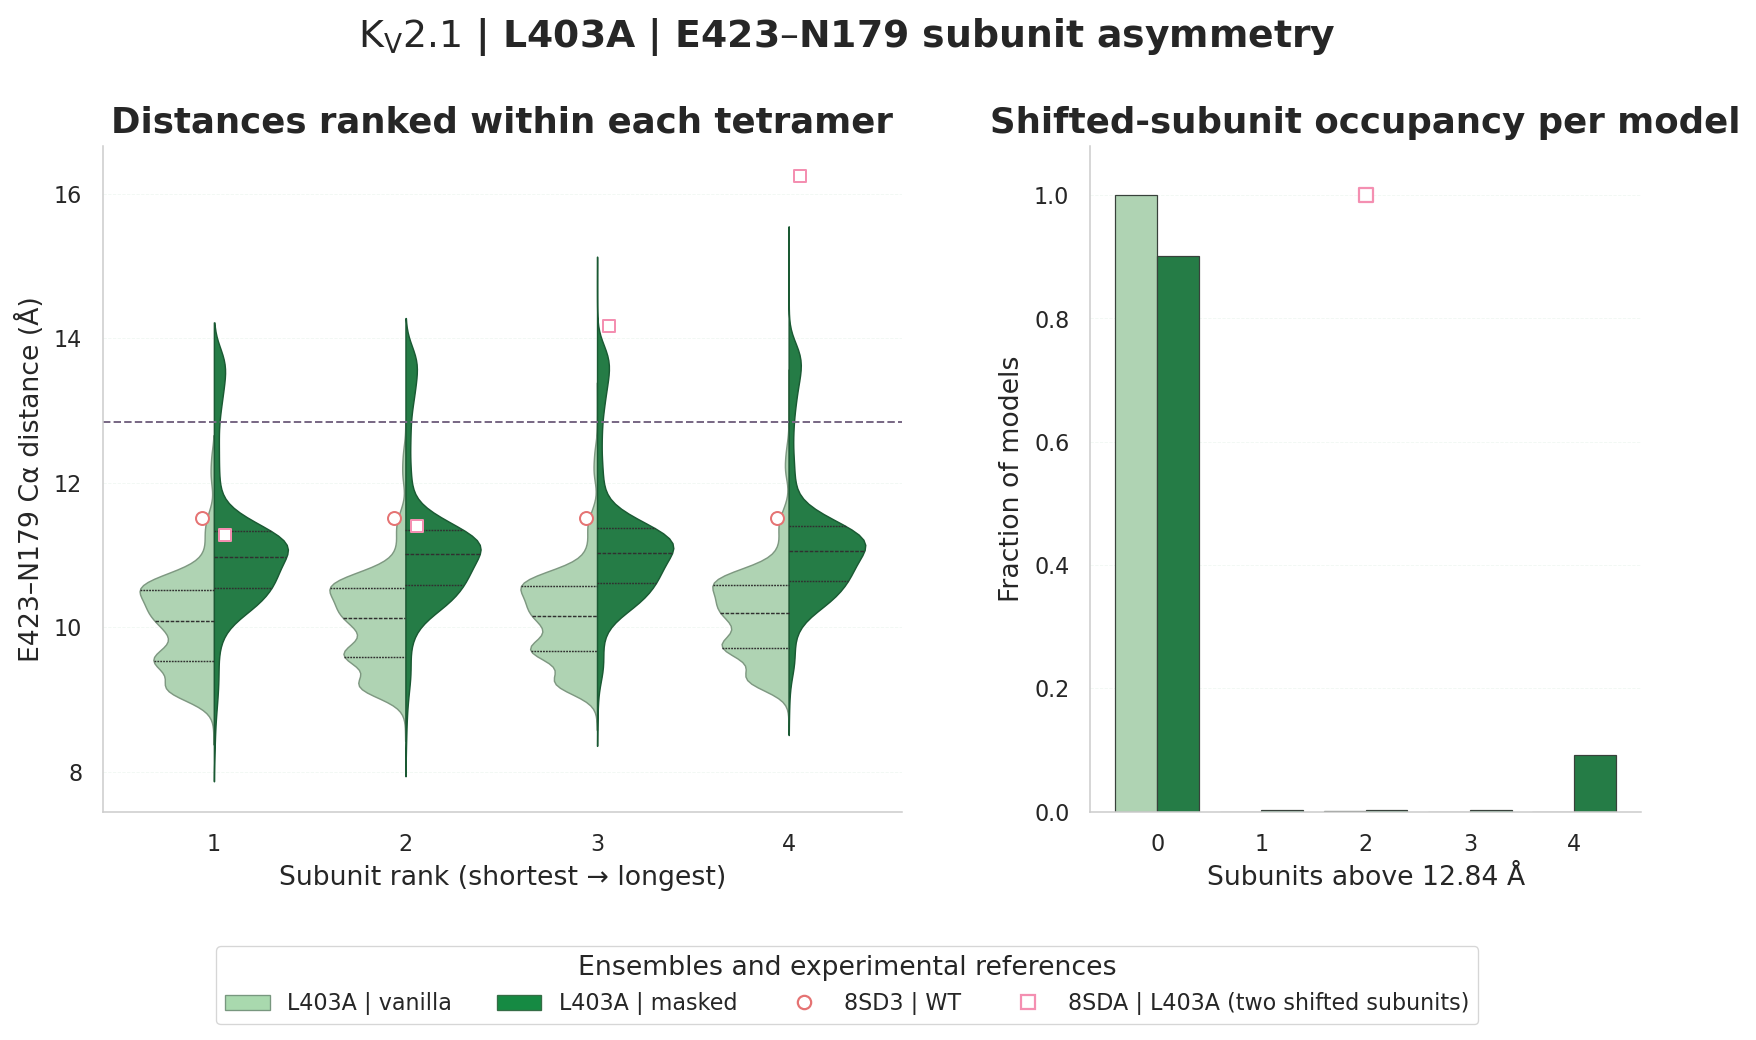

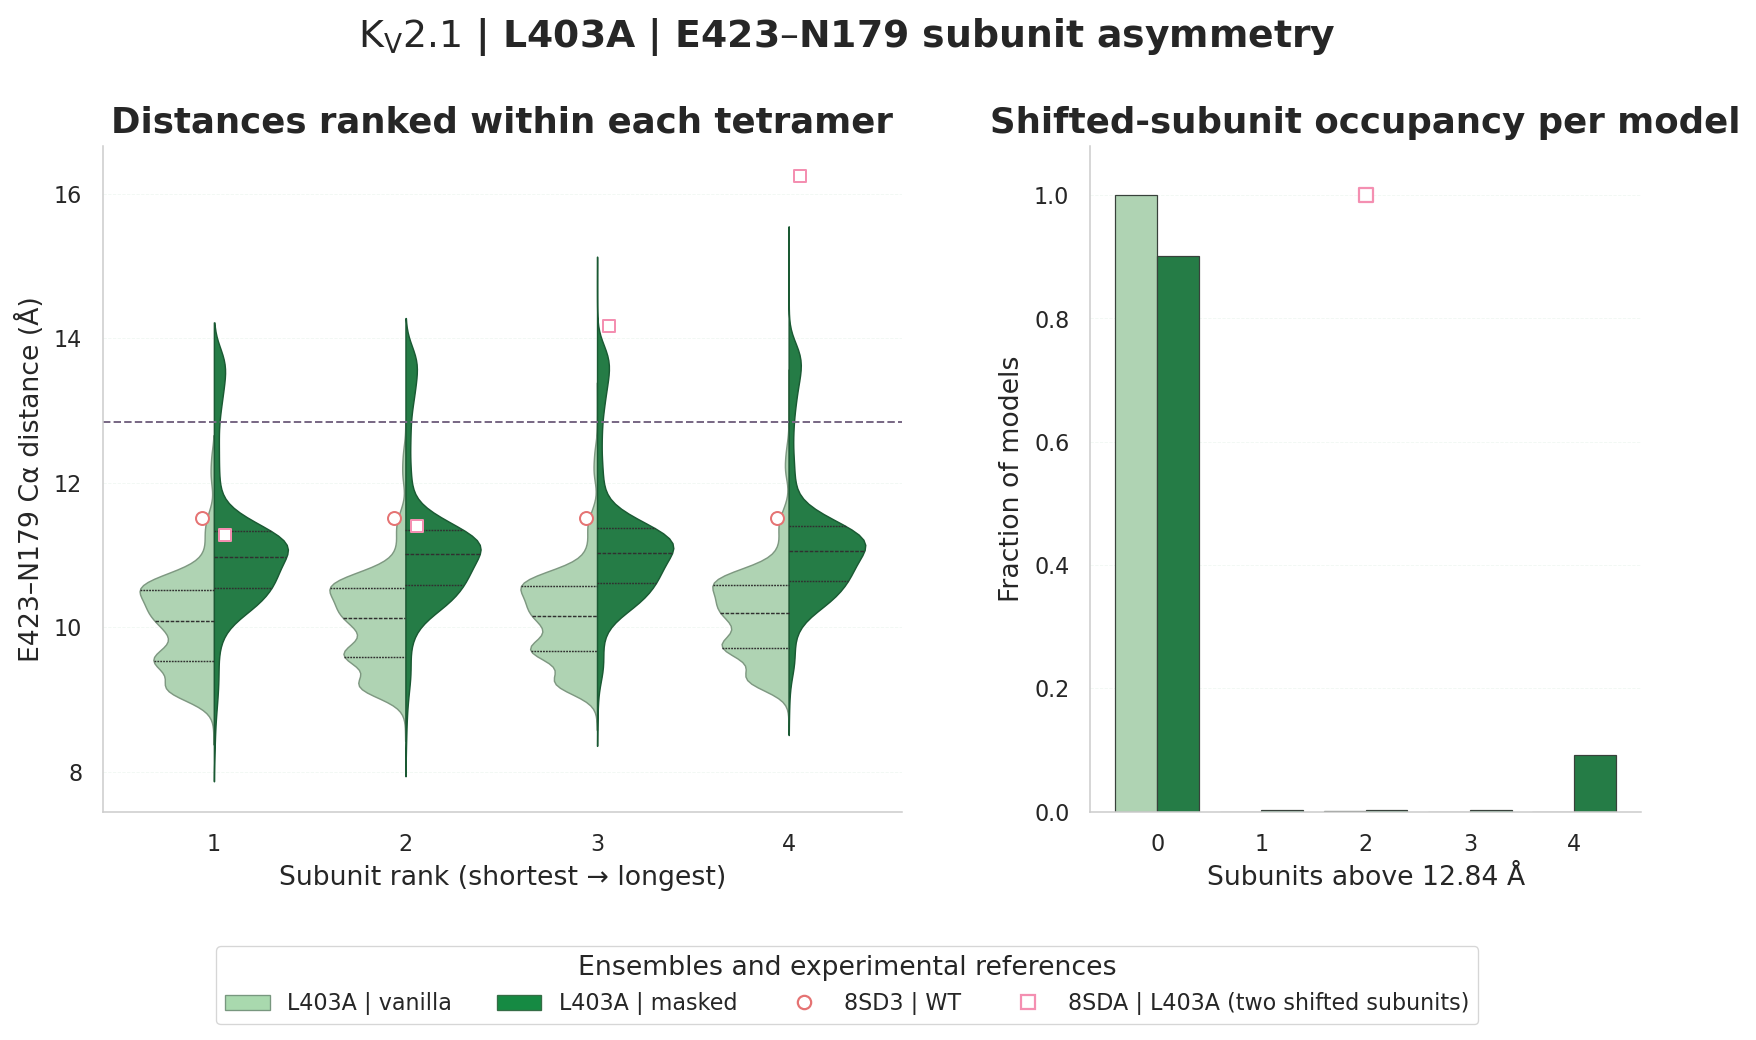

In [11]:
e423_model_table, e423_occupancy, e423_shift_threshold, e423_asymmetry_figure = plot_l403a_e423_n179_asymmetry(
    df_l403a_vanilla,
    df_l403a_masked,
    chain_aliases,
    protocol_exp_distances[0],
    protocol_exp_distances[1],
)
display(e423_occupancy.pivot(index='Shifted subunits', columns='Protocol', values='Fraction of models').fillna(0).round(4))
display(e423_asymmetry_figure)

e423_table_dir = repo_root / 'kv21' / 'dataDistances' / 'analysis' / 'tables'
e423_figure_dir = repo_root / 'kv21' / 'dataDistances' / 'analysis' / 'figures'
e423_table_dir.mkdir(parents=True, exist_ok=True)
e423_figure_dir.mkdir(parents=True, exist_ok=True)
e423_model_table.to_csv(e423_table_dir / 'l403a_e423_n179_model_asymmetry.csv', index=False)
e423_occupancy.to_csv(e423_table_dir / 'l403a_e423_n179_shifted_subunit_occupancy.csv', index=False)
e423_asymmetry_figure.savefig(e423_figure_dir / 'Kv21_L403A_E423-N179_subunit_asymmetry.png', dpi=400, bbox_inches='tight')
e423_asymmetry_figure.savefig(e423_figure_dir / 'Kv21_L403A_E423-N179_subunit_asymmetry.pdf', bbox_inches='tight')


## Experimental reference set used in the figures


## Top mutation-induced shifts


In [12]:
## Largest WT → L403A shifts (top 20)
shift_rows=[]
for alias,col in chain_aliases.items():
    wt=pd.to_numeric(df_wt_masked[col],errors="coerce").dropna().median()
    mut=pd.to_numeric(df_l403a_masked[col],errors="coerce").dropna().median()
    shift_rows.append({"distance":alias,"WT_median_A":wt,"L403A_median_A":mut,"median_shift_A":mut-wt})
shift_table=pd.DataFrame(shift_rows).dropna().sort_values("median_shift_A",key=lambda x:x.abs(),ascending=False).head(20)
display(shift_table)


,distance,WT_median_A,L403A_median_A,median_shift_A
3,E423A-V182A,18.270,18.10,-0.170
15,E423C-V182C,18.285,18.12,-0.165
22,K420D-N179D,14.080,13.92,-0.160
21,E423D-V182D,18.270,18.11,-0.160
10,K420B-N179B,14.100,13.95,-0.150
16,K420C-N179C,14.100,13.95,-0.150
9,E423B-V182B,18.270,18.12,-0.150
14,E423C-N179C,11.160,11.02,-0.140
4,K420A-N179A,14.080,13.94,-0.140
5,K420A-V182A,20.975,20.84,-0.135


## Experimental shift overview


,Protocol,Partner,WT median (Å),Mutant median (Å),Mutant − WT (Å),WT contact ≤4 Å,Mutant contact ≤4 Å,Mutant overlap <2 Å,n
71,masked,PHE414D,15.5,4.7,-10.8,0.014,0.045,0.0,3693
73,masked,LEU318D,19.3,5.3,-14.0,0.391,0.012,0.0,3693
59,masked,PHE414B,18.3,25.3,7.0,0.009,0.011,0.0,3693
61,masked,LEU318B,19.6,26.3,6.7,0.429,0.006,0.0,3693
67,masked,LEU318C,19.5,21.0,1.5,0.025,0.003,0.0,3693
65,masked,PHE414C,15.7,17.7,2.0,0.002,0.002,0.0,3693
70,masked,VAL411D,13.1,7.1,-6.0,0.001,0.000,0.0,3693
20,vanilla,PHE414B,5.5,4.6,-0.9,0.000,0.000,0.0,4371
22,vanilla,LEU318B,3.3,4.8,1.5,0.774,0.000,0.0,4371
19,vanilla,VAL411B,4.4,5.2,0.8,0.000,0.000,0.0,4371


,Structure,Site,Site chain,Partner,Partner paper label,Shortest distance (Å)
0,8SD3,WT L403,A,PHE414D,F412D,15.244
1,8SD3,WT L403,A,LEU318D,L316D,20.166
2,8SD3,WT L403,A,PHE414B,F412B,3.773
3,8SDA,L403A A403,A,PHE414D,F412D,20.967
4,8SDA,L403A A403,A,LEU318D,L316D,24.501
5,8SDA,L403A A403,A,PHE414B,F412B,3.547


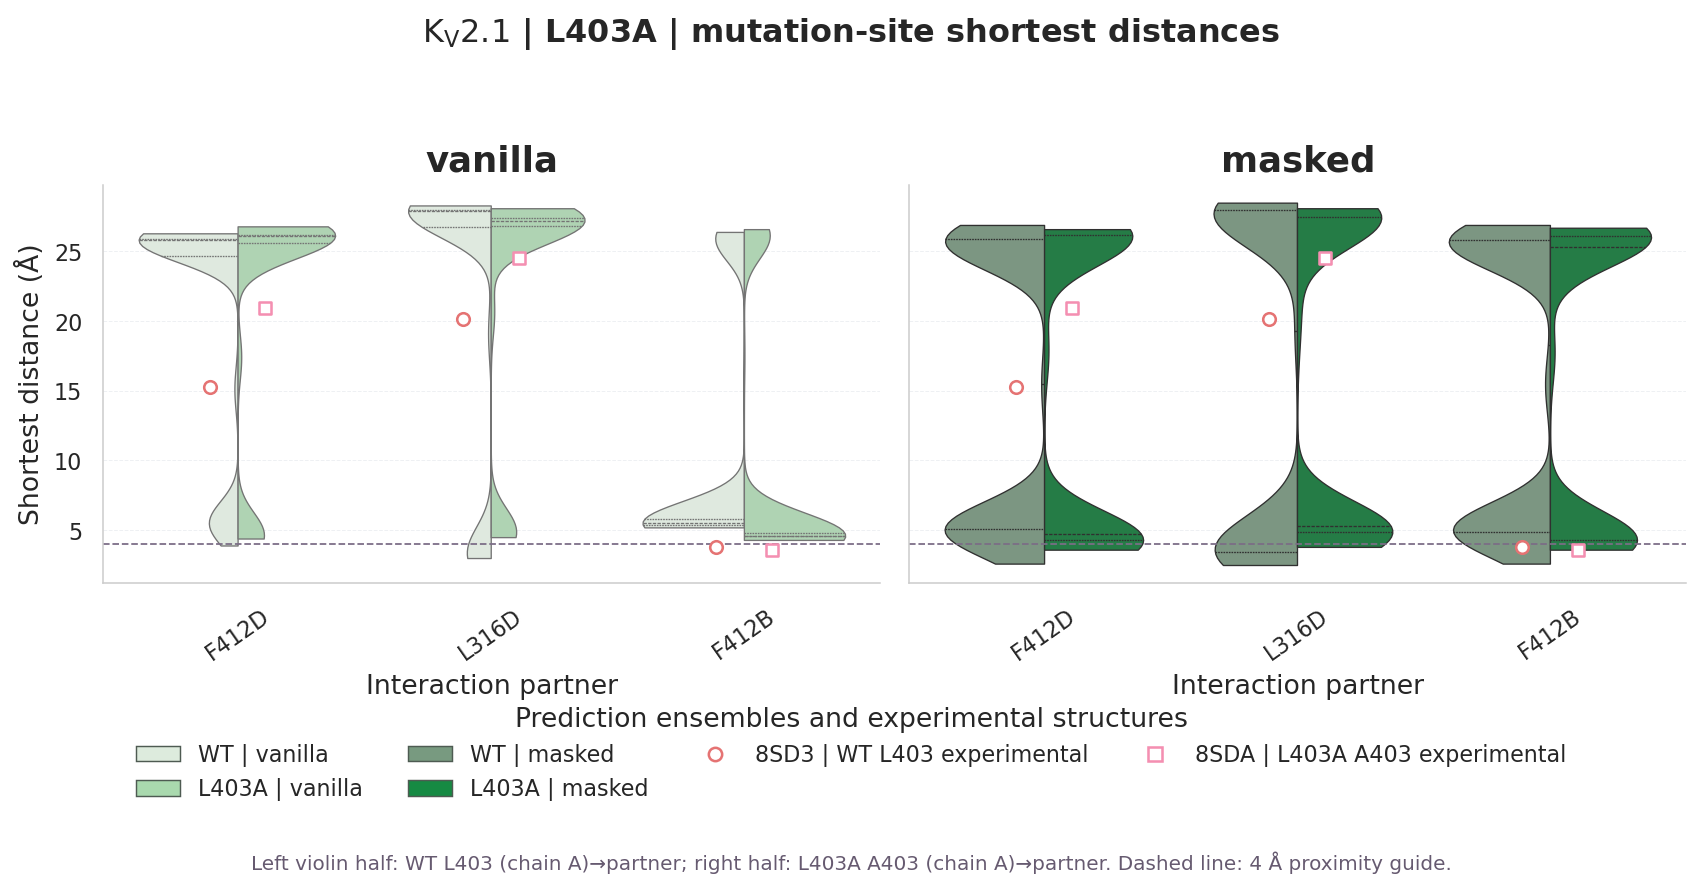

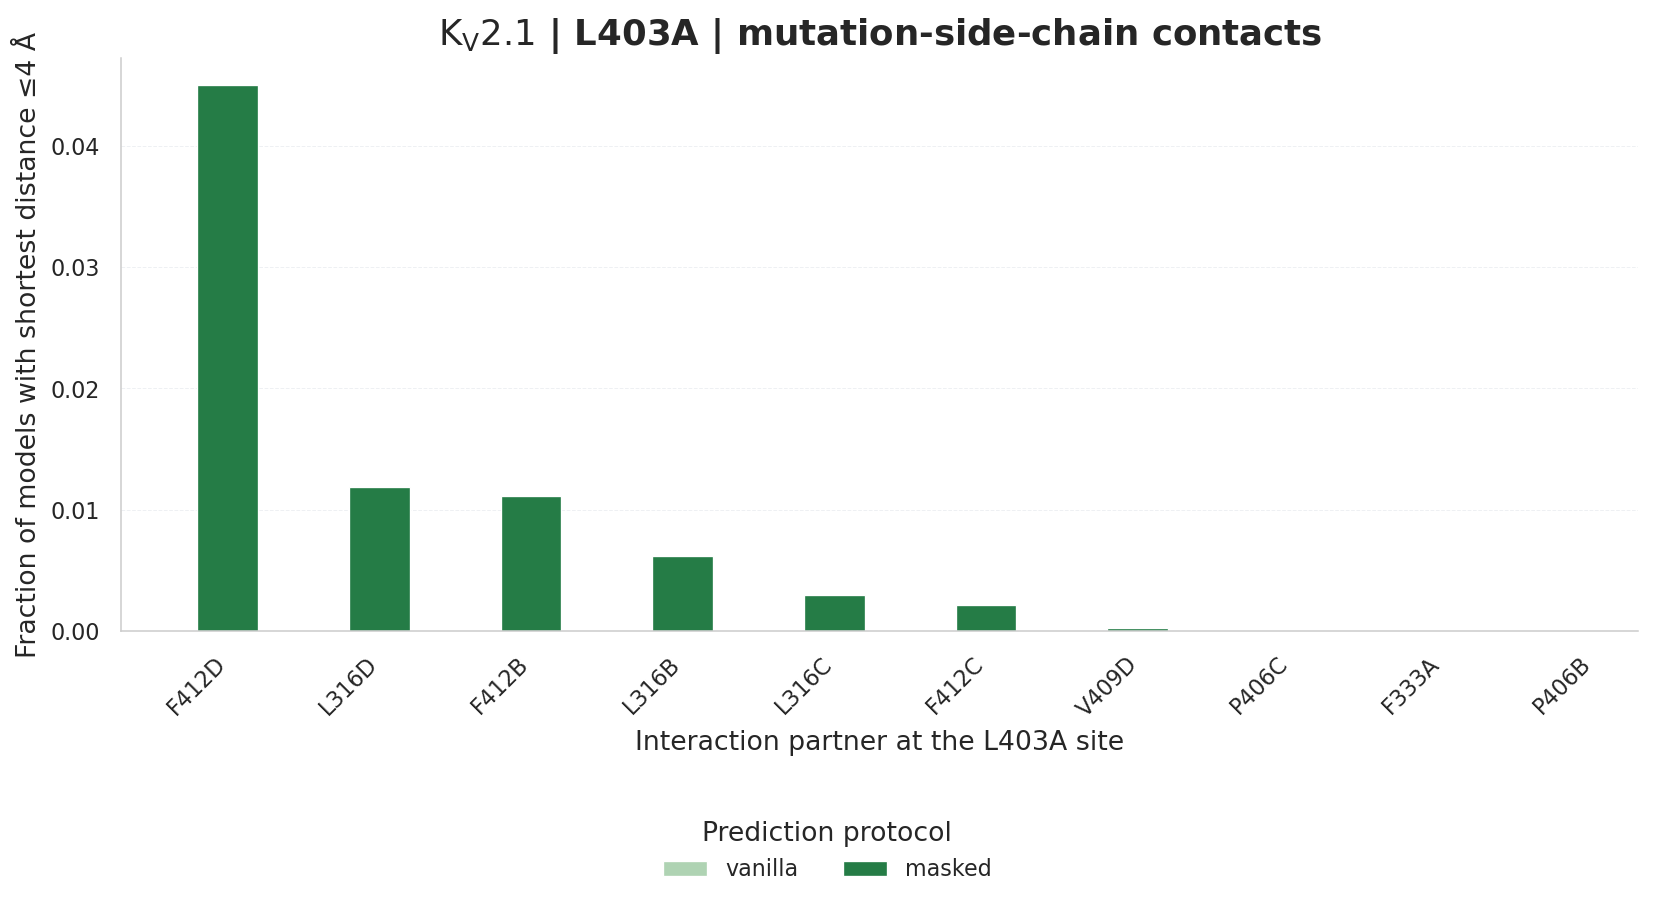

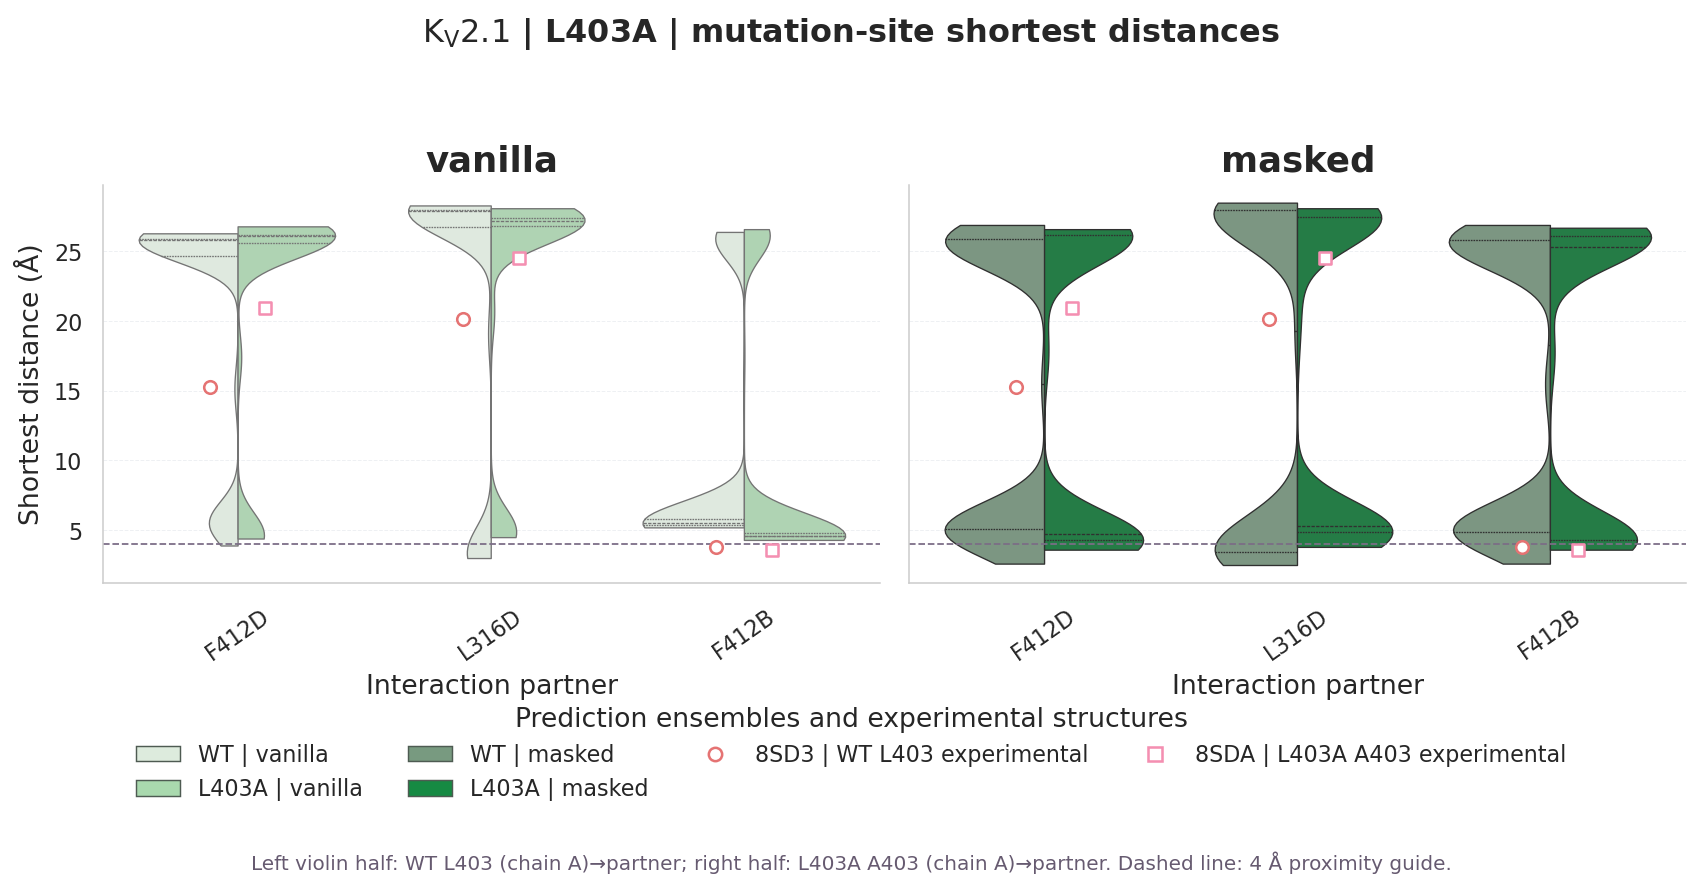

In [13]:
import importlib
## Contacts altered by L403A (model/CSV L405A)
import shared.plotting as shared_plotting
importlib.reload(shared_plotting)
import shared.mutation_contact_analysis as mutation_contact_analysis
importlib.reload(mutation_contact_analysis)
from shared.mutation_contact_analysis import (
    plot_mutation_contacts, plot_selected_contact_distributions,
    kv21_l403a_experimental_shortest_distances,
)
l403a_contact_table, _ = plot_mutation_contacts(
    {'vanilla': (df_wt_vanilla, df_l403a_vanilla), 'masked': (df_wt_masked, df_l403a_masked)},
    'LEU405A', 'ALA405A', 'L403A',
    {'vanilla': KV21_PALETTE['L403A_VAN'], 'masked': KV21_PALETTE['L403A_HM']}, channel='Kv2.1',
)
display(l403a_contact_table.head(15).round(3))
l403a_top_partners = list(dict.fromkeys(l403a_contact_table['Partner']))[:3]
l403a_experimental_shortest = kv21_l403a_experimental_shortest_distances(
    repo_root, l403a_top_partners
)
display(l403a_experimental_shortest.round(3))
contact_table_dir = repo_root / 'kv21' / 'dataDistances' / 'analysis' / 'tables'
contact_table_dir.mkdir(parents=True, exist_ok=True)
l403a_experimental_shortest.to_csv(
    contact_table_dir / 'l403a_experimental_shortest_distances.csv', index=False
)
l403a_contact_distributions, l403a_contact_figure = plot_selected_contact_distributions(
    {'vanilla': (df_wt_vanilla, df_l403a_vanilla), 'masked': (df_wt_masked, df_l403a_masked)},
    'LEU405A', 'ALA405A', 'L403A', l403a_top_partners,
    {'vanilla': (KV21_PALETTE['WT_VAN'], KV21_PALETTE['L403A_VAN']), 'masked': (KV21_PALETTE['WT_HM'], KV21_PALETTE['L403A_HM'])}, channel='Kv2.1',
    show_overlap_region=False,
    experimental_distances=l403a_experimental_shortest,
)
display(l403a_contact_figure)
contact_figure_dir = repo_root / 'kv21' / 'dataDistances' / 'analysis' / 'figures'
contact_figure_dir.mkdir(parents=True, exist_ok=True)
l403a_contact_figure.savefig(
    contact_figure_dir / 'l403a_mutation_site_shortest_distances.png',
    dpi=400, bbox_inches='tight',
)


## Mutation-site model closest to the 8SDA side-chain contact geometry

This ranking uses the root-mean-square error across the three plotted shortest heavy-atom distances from A403 to F412D, L316D, and F412B. It measures agreement with the local 8SDA contact geometry after the final structural/interface QC. It is a side-chain **contact-distance RMSE**, not a Cartesian all-atom RMSD.


In [14]:
# l403a_sidechain_contact_ranking
import numpy as np

reference_vector = (
    l403a_experimental_shortest
    .query("Structure == '8SDA'")
    .set_index('Partner')['Shortest distance (Å)']
)
score_columns = {partner: f'shortest_ALA405A-{partner}' for partner in reference_vector.index}
paper_labels = (l403a_experimental_shortest.drop_duplicates('Partner').set_index('Partner')['Partner paper label'])
ranking_parts = []
for protocol, frame in {'vanilla': df_l403a_vanilla, 'masked': df_l403a_masked}.items():
    observed = frame[list(score_columns.values())].apply(pd.to_numeric, errors='coerce')
    observed.columns = list(score_columns)
    score = np.sqrt(observed.sub(reference_vector, axis='columns').pow(2).mean(axis=1))
    part = pd.DataFrame({
        'Protocol': protocol,
        'pdb_file': frame['pdb_file'].astype(str),
        'A403 contact-distance RMSE to 8SDA (Å)': score,
    })
    for partner in reference_vector.index:
        part[f'A403–{paper_labels[partner]} (Å)'] = observed[partner]
        part[f'8SDA A403–{paper_labels[partner]} (Å)'] = reference_vector[partner]
    ranking_parts.append(part)

l403a_sidechain_contact_ranking = (
    pd.concat(ranking_parts, ignore_index=True)
    .dropna(subset=['A403 contact-distance RMSE to 8SDA (Å)'])
    .sort_values('A403 contact-distance RMSE to 8SDA (Å)')
    .reset_index(drop=True)
)

print('Smallest mutation-site side-chain contact-distance RMSE to 8SDA')
display(l403a_sidechain_contact_ranking.head(1).round(3))
print('Best model within each prediction protocol')
display(
    l403a_sidechain_contact_ranking
    .groupby('Protocol', sort=False, as_index=False)
    .head(1)
    .round(3)
)
l403a_sidechain_contact_ranking.to_csv(
    contact_table_dir / 'l403a_sidechain_contact_distance_ranking.csv', index=False
)


Smallest mutation-site side-chain contact-distance RMSE to 8SDA


,Protocol,pdb_file,A403 contact-distance RMSE to 8SDA (Å),A403–F412D (Å),8SDA A403–F412D (Å),A403–L316D (Å),8SDA A403–L316D (Å),A403–F412B (Å),8SDA A403–F412B (Å)
0,masked,kv21_l403a_masked_unrelaxed_rank_416_alphafold...,2.094,24.5,20.967,25.1,24.501,4.1,3.547


Best model within each prediction protocol


,Protocol,pdb_file,A403 contact-distance RMSE to 8SDA (Å),A403–F412D (Å),8SDA A403–F412D (Å),A403–L316D (Å),8SDA A403–L316D (Å),A403–F412B (Å),8SDA A403–F412B (Å)
0,masked,kv21_l403a_masked_unrelaxed_rank_416_alphafold...,2.094,24.5,20.967,25.1,24.501,4.1,3.547
5,vanilla,kv21_l403a_unrelaxed_alphafold2_multimer_v3_mo...,2.400,24.6,20.967,26.0,24.501,4.9,3.547
